In [1]:
%%writefile /tmp/gen_fe.py
GROUPS = 150
REGS = "abcdefgh"

lines = []
for g in range(GROUPS):
    lines.append("    " + " ".join(f'__asm__("" : "+r"({r}));' for r in REGS))
    lines.append(
        "    "
        + " ".join(f"{r} += {g * len(REGS) + k + 1};" for k, r in enumerate(REGS))
    )

source = f"""
extern "C" long fe_code(long a, long b, long c, long d) {{
    long e = a + 1, f = b + 1, g = c + 1, h = d + 1;
{chr(10).join(lines)}
    return a + b + c + d + e + f + g + h;
}}
"""

with open("/tmp/study_fe.cpp", "w") as fh:
    fh.write(source)


Overwriting /tmp/gen_fe.py


In [2]:
!python /tmp/gen_fe.py && cat /tmp/study_fe.cpp


extern "C" long fe_code(long a, long b, long c, long d) {
    long e = a + 1, f = b + 1, g = c + 1, h = d + 1;
    __asm__("" : "+r"(a)); __asm__("" : "+r"(b)); __asm__("" : "+r"(c)); __asm__("" : "+r"(d)); __asm__("" : "+r"(e)); __asm__("" : "+r"(f)); __asm__("" : "+r"(g)); __asm__("" : "+r"(h));
    a += 1; b += 2; c += 3; d += 4; e += 5; f += 6; g += 7; h += 8;
    __asm__("" : "+r"(a)); __asm__("" : "+r"(b)); __asm__("" : "+r"(c)); __asm__("" : "+r"(d)); __asm__("" : "+r"(e)); __asm__("" : "+r"(f)); __asm__("" : "+r"(g)); __asm__("" : "+r"(h));
    a += 9; b += 10; c += 11; d += 12; e += 13; f += 14; g += 15; h += 16;
    __asm__("" : "+r"(a)); __asm__("" : "+r"(b)); __asm__("" : "+r"(c)); __asm__("" : "+r"(d)); __asm__("" : "+r"(e)); __asm__("" : "+r"(f)); __asm__("" : "+r"(g)); __asm__("" : "+r"(h));
    a += 17; b += 18; c += 19; d += 20; e += 21; f += 22; g += 23; h += 24;
    __asm__("" : "+r"(a)); __asm__("" : "+r"(b)); __asm__("" : "+r"(c)); __asm__("" : "+r"(d)); __asm__("

In [3]:
!g++ -O3 -c /tmp/study_fe.cpp -o /tmp/study_fe.o

In [4]:
import subprocess

text = subprocess.run(
    ["objdump", "-d", "--no-show-raw-insn", "/tmp/study_fe.o"],
    capture_output=True,
    text=True,
    check=True,
).stdout
body = text.split("<fe_code>:", 1)[1]
insns = [l for l in body.splitlines() if l.strip() and l.strip()[0].isdigit()]
nbytes = int(insns[-1].split(":")[0].strip(), 16)
print(f"{len(insns)} instructions, {nbytes} bytes = {nbytes / 4096:.1f} pages of code")


959 instructions, 7912 bytes = 1.9 pages of code


## Frontend bound: hot vs cold instruction cache

One axis, one function, two tiers. `fe_code` is a large straight-line body that
does **eight independent adds per group** across 150 groups.

Two properties matter, and both are required:

- **High ILP.** Eight independent accumulator chains mean the backend is never
  the limiter, so there is slack for a front-end stall to show up as cycles.
  An earlier version of this notebook used one dependent accumulator. It showed a
  `fe-bound` share of 0.129 but *identical* cycle counts hot and cold — the
  backend simply absorbed the misses, and the axis was not measurable.
- **A footprint that does not fit L1i.** ~1200 instructions over ~2 pages is well
  past what stays resident, so evicting the code has something to cost.

**Claim.** With `icache` set to `cold`, the function retires the same
instructions in far more cycles, and the bound moves: `topdown-fe-bound` becomes
the dominant slot, where with `hot` the dominant slot is `topdown-retiring`.

The tiers are not a simulation: perf evicts code pages with `mprotect`, which
takes the lines out of L1i and the uop cache through coherence, so `cold` pays a
real re-fetch on the next pass.

In [5]:
import pandas as pd

import perf

TARGET = "/tmp/study_fe.o"
FUNC = "fe_code"
DATA = {"regs": {"rdi": 7, "rsi": 8, "rdx": 9, "rcx": 10}}

SLOTS = [
    "topdown-retiring",
    "topdown-bad-spec",
    "topdown-fe-bound",
    "topdown-be-bound",
]
RAW = ["cycles", "instructions"]
TIERS = ["hot", "cold"]

CONFIG = {
    "samples": 25,
    "iterations": 50,
    "branch": "predictable",
    "dcache": "hot",
    "dtlb": "hot",
    "code": {"align": 16},
    "func": {"align": 16, "order": "as-is"},
    "stack": {"size": 0x200000, "align": 16},
    "backend": {"loop": {"runs": 4}},
}


def sweep(event):
    frames = []
    for tier in TIERS:
        df = perf.benchmark(
            code=[TARGET, FUNC],
            mode=["latency"],
            event=event,
            config={**CONFIG, "icache": tier},
            data=DATA,
        ).reset_index()
        df["tier"] = tier
        frames.append(df)
    return pd.concat(frames, ignore_index=True)


def medians(df, columns):
    return df.groupby("tier")[columns].median()


def pct(med):
    return med.div(med.sum(axis=1), axis=0).round(3)


def check(claim, ok):
    print(("PASS  " if ok else "FAIL  ") + claim)
    assert ok, claim


In [6]:
TOP = medians(sweep(SLOTS), SLOTS)
print(TOP.round(1))
print()
print(pct(TOP))

CMP = medians(sweep(RAW), RAW)
CMP["ipc"] = CMP["instructions"] / CMP["cycles"]
print()
print(CMP.round(2))

share = pct(TOP)
hot_cyc = CMP.loc["hot", "cycles"]
cold_cyc = CMP.loc["cold", "cycles"]
hot_insn = CMP.loc["hot", "instructions"]
cold_insn = CMP.loc["cold", "instructions"]

check(
    f"both tiers retire the same instructions "
    f"({hot_insn:.0f} hot vs {cold_insn:.0f} cold)",
    0.99 <= cold_insn / hot_insn <= 1.01,
)
check(
    f"cold costs more cycles ({cold_cyc:.0f} > {hot_cyc:.0f}, "
    f"{cold_cyc / hot_cyc:.2f}x)",
    cold_cyc > 2 * hot_cyc,
)
check(
    f"cold is frontend bound: fe-bound "
    f"{share.loc['cold', 'topdown-fe-bound']} > 0.5 and is the largest slot",
    share.loc["cold", "topdown-fe-bound"] > 0.5
    and share.loc["cold"].idxmax() == "topdown-fe-bound",
)
check(
    f"hot is not: retiring "
    f"{share.loc['hot', 'topdown-retiring']} > 0.5 and is the largest slot",
    share.loc["hot", "topdown-retiring"] > 0.5
    and share.loc["hot"].idxmax() == "topdown-retiring",
)
check(
    f"backend-bound stays small either way "
    f"({share.loc['hot', 'topdown-be-bound']} hot, "
    f"{share.loc['cold', 'topdown-be-bound']} cold) so this is a frontend axis",
    share["topdown-be-bound"].max() < 0.1,
)


      topdown-retiring  topdown-bad-spec  topdown-fe-bound  topdown-be-bound
tier                                                                        
cold            1209.0               NaN            3128.0              88.0
hot             1209.0              25.0             448.0              13.0

      topdown-retiring  topdown-bad-spec  topdown-fe-bound  topdown-be-bound
tier                                                                        
cold             0.273               NaN             0.707             0.020
hot              0.713             0.015             0.264             0.008

      cycles  instructions   ipc
tier                            
cold   779.0        1209.0  1.55
hot    250.0        1209.0  4.84
PASS  both tiers retire the same instructions (1209 hot vs 1209 cold)
PASS  cold costs more cycles (779 > 250, 3.12x)
PASS  cold is frontend bound: fe-bound 0.707 > 0.5 and is the largest slot
PASS  hot is not: retiring 0.713 > 0.5 and is the largest

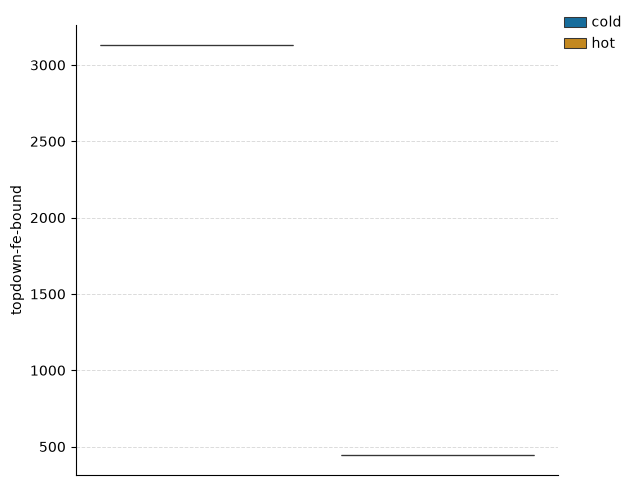

[]

In [7]:
perf.plot(TOP, "boxen", event="topdown-fe-bound", groupby="tier")


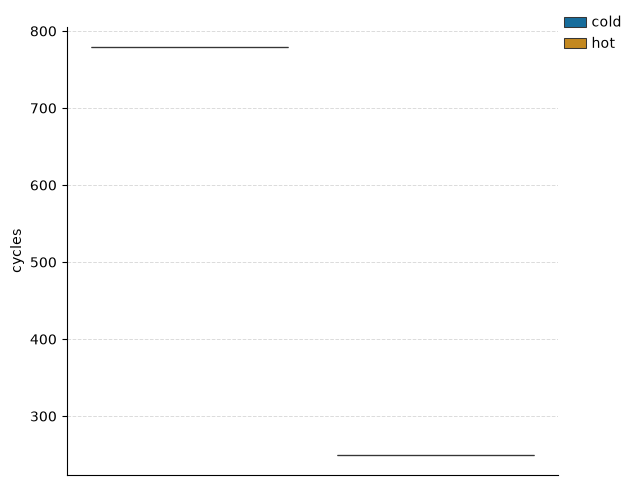

[]

In [8]:
perf.plot(CMP, "boxen", event="cycles", groupby="tier")


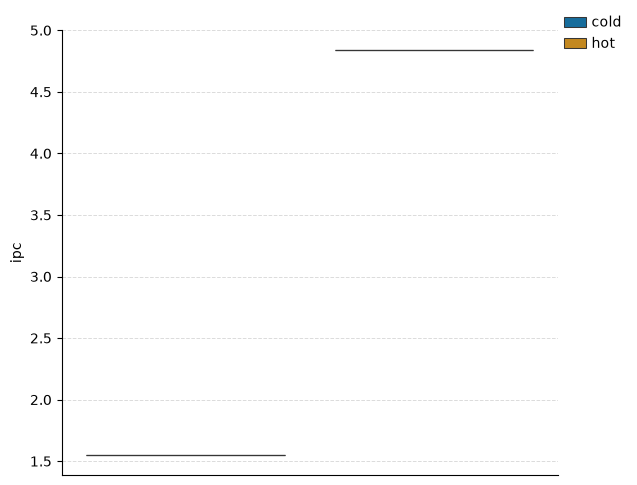

[]

In [9]:
perf.plot(CMP, "boxen", event="ipc", groupby="tier")


## Two axes that did not work, and one that nearly did

**`itlb` was dropped on purpose.** Sweeping `itlb` hot vs cold on the same
function moved cycles only ~4% (528 vs 508) and moved the `fe-bound` share the
*wrong* way — 0.603 cold against 0.698 hot. Including it would have meant
shipping a claim the measurements do not support.

**A dependent chain cannot measure a front-end axis.** The first version of this
notebook used a single accumulator, so each add waited on the previous one. Cold
tiers showed a `fe-bound` share of 0.129 against 0.001 for hot — a 129x ratio
that looks like a dramatic result — while cycles stayed flat at 1115. Nothing had
been demonstrated. The share moved only because the slots re-attributed; no time
was spent. Eight independent accumulators fix it, and the `backend-bound` check
above now fails loudly if the body stops being backend-free.

**The checks assert which slot dominates, not a ratio.** `topdown-fe-bound`
under `hot` is small and noisy — it came out at 0.192, 0.200 and 0.296 across
runs, so a "cold is 3x hot" assertion passes or fails depending on the day. The
stable fact is that `cold` is frontend-bound by a wide margin and `hot` is not
bounded at all, so the checks above test slot dominance and the 0.5 threshold,
which both survive the noise.

**One real trap, shared with the retiring notebook.** A body of `x += constant`
folds to a single `add` at `-O2`, leaving nothing to fetch and nothing to
evict. `__asm__("" : "+r"(x))` keeps each accumulator live and the body real;
the cell above prints the resulting instruction count and code size so the
footprint is visible rather than assumed.